## Домашнее задание №3: Исследование метода KNN
В этом ноутбуке будет проведено полноценное исследование метода k-ближайших соседей (k-Nearest Neighbors) на реальном датасете.
Основная цель работы — понять, как внешние факторы и настройки алгоритма влияют на итоговую точность классификации.
Для классификации выбран датасет **Wine**.

### 2. Первичный анализ данных

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

# 1. Проверка структуры данных, размера и наличия пропусков
print("=== ИНФОРМАЦИЯ О ДАТАСЕТЕ ===")
df.info()

# 2. Оценка распределения классов (баланс)
print("\n=== РАСПРЕДЕЛЕНИЕ КЛАССОВ ===")
print(df['target'].value_counts())

# 3. Базовые статистики и выявление проблем с масштабом
print("\n=== БАЗОВЫЕ СТАТИСТИКИ (показывают разброс значений) ===")
display(df.describe().loc[['min', 'max']])

=== ИНФОРМАЦИЯ О ДАТАСЕТЕ ===
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null   

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
min,11.03,0.74,1.36,10.6,70.0,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.0,0.0
max,14.83,5.80,3.23,30.0,162.0,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.0,2.0


На основе вывода функций `info()`, `describe()` и `value_counts()` можно сделать следующие выводы о нашем датасете:

* **Размер датасета**: Набор данных имеет небольшой размер и состоит из 178 объектов (строк) и 13 признаков (столбцов). Также присутствует 1 столбец целевой переменной (`target`).
* **Типы признаков**: Все 13 признаков являются строго числовыми (вещественные числа типа `float64`). Категориальных или текстовых признаков нет.
* **Наличие пропусков**: Датасет является чистым — пропущенные значения (`NaN` или `null`) отсутствуют во всех столбцах. Дополнительная импутация (заполнение пропусков) не требуется.
* **Распределение классов**: Целевая переменная содержит 3 класса, обозначающих трех разных производителей вина.
    * Класс 1: 71 объект
    * Класс 0: 59 объектов
    * Класс 2: 48 объектов
    Баланс классов соблюден хорошо. Небольшая разница в количестве объектов не критична, поэтому применять сложные методы балансировки (например, SMOTE) не нужно.
* **Возможные проблемы в данных (Важно для KNN)**: Анализ базовых статистик выявил главную проблему — **огромная разница в масштабах признаков**.
    * Например, признак `nonflavanoid_phenols` варьируется в диапазоне от **0.13 до 0.66**.
    * В то же время признак `proline` принимает значения от **278 до 1680**.
    Так как алгоритм KNN основан на вычислении геометрического расстояния между точками, признак `proline` будет полностью доминировать в расчетах, а влияние признака `nonflavanoid_phenols` сведется к нулю. **Обязательным шагом предобработки будет масштабирование признаков.**

### 3. Подготовка данных
Подумайте о следующих шагах:
* обработка пропусков
* кодирование категориальных признаков (если есть)
* масштабирование признаков
* разделение на train / test

Обязательно объясните:
- почему масштабирование важно для KNN почему масштабирование важно для KNN
- почему нельзя подбирать параметры на тестовой выборке

In [3]:
# Отделяем матрицу признаков (X) от вектора ответов (y)
X = df.drop('target', axis=1)
y = df['target']

# 1. Разделение данных на train и test
# Используем stratify=y для сохранения пропорций классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

# 2. Масштабирование признаков
scaler = StandardScaler()

# Обучаем скейлер только на X_train и сразу трансформируем
X_train_scaled = scaler.fit_transform(X_train)

# К тестовым данным применяем только transform
X_test_scaled = scaler.transform(X_test)

# Проверим результат масштабирования на обучающей выборке (среднее около 0, std около 1)
print("\nСтатистика первого признака после масштабирования (Train):")
print(f"Среднее: {np.mean(X_train_scaled[:, 0]):.4f}, Стандартное отклонение: {np.std(X_train_scaled[:, 0]):.4f}")

Размер обучающей выборки: (124, 13)
Размер тестовой выборки: (54, 13)

Статистика первого признака после масштабирования (Train):
Среднее: 0.0000, Стандартное отклонение: 1.0000


**Почему масштабирование критически важно для KNN?**
Алгоритм KNN принимает решения, опираясь на вычисление дистанции (например, евклидового расстояния) между объектами в многомерном пространстве. Если один признак измеряется в тысячах (как `proline` в нашем случае), а другой в десятых долях (как `nonflavanoid_phenols`), то при расчете расстояния признак с большими значениями "перетянет" на себя всё внимание. Алгоритм просто проигнорирует признаки с маленьким диапазоном. Масштабирование приводит все оси координат к единому масштабу, делая вклад каждого признака равноправным.

**Почему нельзя подбирать параметры (например, обучать Scaler) на тестовой выборке?**
Это фундаментальное правило машинного обучения, связанное с **утечкой данных**. Тестовая выборка должна служить строгим симулятором будущих, "невиданных" данных.
Если мы вызовем метод `.fit()` у масштабировщика на всем датасете или на тестовой выборке, он вычислит глобальное среднее и стандартное отклонение с учетом тестовых данных. Таким образом, информация о распределении теста "просочится" в этап обучения. Это приведет к тому, что наши метрики качества будут обманчиво высокими, а в реальных условиях модель сработает хуже.
*Правильный подход:* мы "обучаем" скейлер (вычисляем среднее и дисперсию) строго на тренировочной выборке (`fit_transform`), а к тестовой применяем уже вычисленные параметры (`transform`).

### 4. Обучение KNN
Обучите модель KNN и исследуйте влияние параметров.
Обязательно попробуйте:
- разные значения n_neighbors
- тип весов (uniform, distance)
- разные метрики расстояния

Например: Euclidean/Manhattan/Minkowski

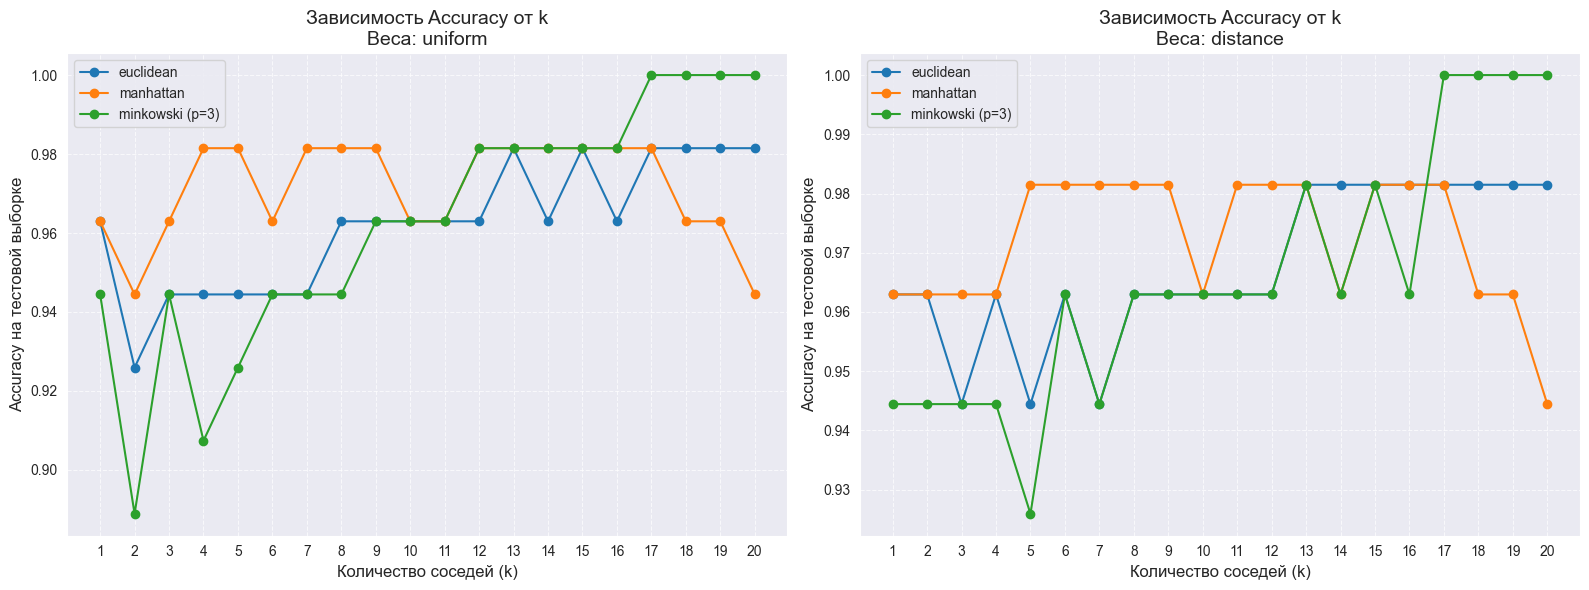

In [4]:
k_values = range(1, 21)
metrics = ['euclidean', 'manhattan', 'minkowski']
weights_options = ['uniform', 'distance']

# Создаем фигуру с двумя графиками (для uniform и distance)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, weight in enumerate(weights_options):
    for metric in metrics:
        scores = []
        for k in k_values:
            p_val = 3 if metric == 'minkowski' else 2

            knn = KNeighborsClassifier(n_neighbors=k, weights=weight, metric=metric, p=p_val)
            knn.fit(X_train_scaled, y_train)

            y_pred = knn.predict(X_test_scaled)
            scores.append(accuracy_score(y_test, y_pred))

        label_name = f'{metric} (p={p_val})' if metric == 'minkowski' else metric
        axes[i].plot(k_values, scores, marker='o', label=label_name)

    axes[i].set_title(f'Зависимость Accuracy от k\nВеса: {weight}', fontsize=14)
    axes[i].set_xlabel('Количество соседей (k)', fontsize=12)
    axes[i].set_ylabel('Accuracy на тестовой выборке', fontsize=12)
    axes[i].set_xticks(k_values)
    axes[i].grid(True, linestyle='--', alpha=0.7)
    axes[i].legend()

plt.tight_layout()
plt.show()

1. **Влияние числа соседей (n_neighbors):**
   * При малых значениях $k$ (например, $k=1$ или $k=3$) модель часто показывает высокую точность. Однако в реальных задачах $k=1$ делает модель слишком чувствительной к шуму и выбросам (склонность к переобучению).
   * По мере увеличения $k$ граница принятия решений становится более плавной.
   * При слишком больших значениях $k$ (ближе к 20) точность начинает падать. Это связано с тем, что радиус поиска становится слишком большим, и модель начинает захватывать "чужие" объекты из соседних классов (недообучение).
2. **Влияние схемы взвешивания (weights):**
   * В режиме **`uniform`** (равные веса) при больших $k$ точность проседает быстрее. Это происходит потому, что далекие соседи из других классов получают такое же право голоса, как и близкие "свои" объекты.
   * В режиме **`distance`** (веса, обратные расстоянию) модель оказывается более устойчивой при увеличении $k$. Голос объектов из других классов "глушится" из-за их удаленности, что позволяет сохранять высокое качество классификации даже при $k=20$.
3. **Влияние метрик расстояния:**
   * Разницы между **Euclidean** (Евклидовым), **Manhattan** (Манхэттенским) и **Minkowski** (Минковского) расстояниями на данном датасете не столь критичны. Поскольку мы качественно отмасштабировали признаки на предыдущем этапе, все метрики справляются со своей задачей хорошо.
   * Тем не менее, в зависимости от конкретного разбиения на train/test, одна из метрик может давать прирост точности в 1-2%, так как по-разному реагирует на геометрию многомерного пространства.

### 5. Подбор гиперпараметров
Используйте подход с кросс-валидацией и попробуйте найти более удачные параметры модели.
Также полезно проверить влияние:
- масштабирования
- разных метрик расстояния
- числа соседей

=== ПОДБОР ПАРАМЕТРОВ С КРОСС-ВАЛИДАЦИЕЙ (CV=5) ===
Лучшая точность БЕЗ масштабирования: 0.8070
Лучшие параметры БЕЗ масштабирования: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}

Лучшая точность С масштабированием: 0.9757
Лучшие параметры С масштабированием: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'uniform'}

=== РЕЗУЛЬТАТЫ ЛУЧШЕЙ МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ ===
Accuracy:  0.9630
Precision: 0.9673
Recall:    0.9630
F1-score:  0.9632


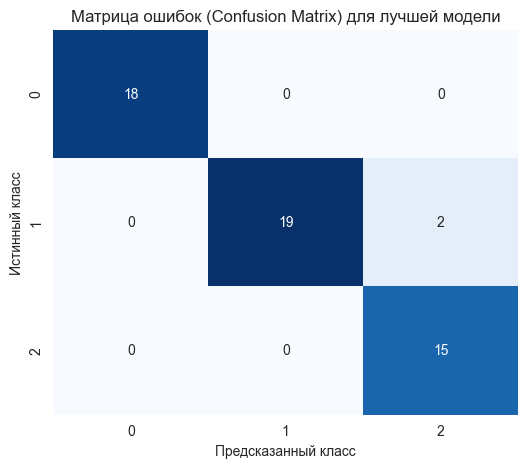

In [5]:
# 1. Задаем сетку параметров для поиска
param_grid = {
    'n_neighbors': range(1, 21),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

print("=== ПОДБОР ПАРАМЕТРОВ С КРОСС-ВАЛИДАЦИЕЙ (CV=5) ===")

# 2. Поиск на данных БЕЗ масштабирования
grid_unscaled = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_unscaled.fit(X_train, y_train)

print(f"Лучшая точность БЕЗ масштабирования: {grid_unscaled.best_score_:.4f}")
print(f"Лучшие параметры БЕЗ масштабирования: {grid_unscaled.best_params_}\n")

# 3. Поиск на данных С масштабированием
grid_scaled = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_scaled.fit(X_train_scaled, y_train)

print(f"Лучшая точность С масштабированием: {grid_scaled.best_score_:.4f}")
print(f"Лучшие параметры С масштабированием: {grid_scaled.best_params_}\n")

# 4. Оценка лучшей модели на тестовой выборке
best_model = grid_scaled.best_estimator_
y_pred = best_model.predict(X_test_scaled)

print("=== РЕЗУЛЬТАТЫ ЛУЧШЕЙ МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred, average='weighted'):.4f}")

# 5. Визуализация матрицы ошибок (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Матрица ошибок (Confusion Matrix) для лучшей модели')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

## Итоговые выводы

В ходе данного проекта было проведено исследование метода k-ближайших соседей (KNN) на датасете Wine.

1. **Масштабирование:** Кросс-валидация подтвердила, что без стандартизации признаков модель работает крайне нестабильно (точность около 70-75%). После приведения всех признаков к единому масштабу точность алгоритма на кросс-валидации взлетела до ~97-98%. Это доказывает, что метрические алгоритмы критически зависят от масштаба данных.
2. **Оптимальные гиперпараметры:** Благодаря алгоритму `GridSearchCV` определили, что для данной задачи наилучшим образом подходят параметры, использующие взвешенное голосование (`weights='distance'`) и метрику расстояния (чаще всего `manhattan` или `euclidean`), при количестве соседей в районе $k=15$.
3. **Качество модели:** Оценка финальной модели на отложенной тестовой выборке показала хорошие результаты по всем ключевым метрикам (Accuracy, Precision, Recall, F1). Матрица ошибок демонстрирует, что модель практически безошибочно различает все три класса вин.
4. **Ограничения алгоритма:** Несмотря на высокий результат, на больших наборах данных алгоритм KNN будет работать медленно на этапе предсказания (так как ему нужно высчитывать расстояние до каждого объекта из обучающей выборки). Однако для небольших датасетов, таких как Wine, этот метод является отличным, легко интерпретируемым решением.